In [48]:
from __future__ import annotations
import xmltodict
from pathlib import Path
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pydantic import BaseModel
from typing import Literal
from rdkit import Chem
from functools import cached_property
from rdkit.Chem import AllChem, rdMolTransforms

def _parse_angles(raw: list[dict] | dict) -> list[Angle]:
    if isinstance(raw, dict):
        raw = [raw]
    return [
        Angle(
            value=float(r["@value"]),
            tolerance1=float(r["@tolerance1"]),
            tolerance2=float(r["@tolerance2"]),
            score=float(r["@score"]),
        )
        for r in raw
    ]
    
    
class Angle(BaseModel):
    value: float
    tolerance1: float  # relaxed threshold
    tolerance2: float  # tolerance threshold
    score: float

    def angular_distance(self, angle: float) -> float:
        """Handles wrap-around (e.g. 179° vs -179° are only 2° apart)."""
        diff = (angle - self.value + 180) % 360 - 180
        return abs(diff)

    def classify(self, angle: float) -> Literal["relaxed", "tolerated", "strain"]:
        dist = self.angular_distance(angle)
        if dist <= self.tolerance1:
            return "relaxed"
        elif dist <= self.tolerance2:
            return "tolerance"
        else:
            return "strain"

class Rule(BaseModel):
    smarts: str
    level: int
    hierarchy: list[dict]
    angles: list[Angle]
    csd_counts: list[int]

    @cached_property
    def pattern(self):
        return Chem.MolFromSmarts(self.smarts)

    @cached_property
    def torsion_indices(self):
        return [
                atom.GetIdx()
                for atom in sorted(self.pattern.GetAtoms(), key=lambda a: a.GetAtomMapNum())
                if atom.GetAtomMapNum() > 0
            ]

    def query(self, angle: float) -> dict:
        """Find the nearest region and classify the given angle."""
        nearest = min(self.angles, key=lambda r: r.angular_distance(angle))
        return {
            "angle": angle,
            "nearest_value": nearest.value,
            "status": nearest.classify(angle),
            "score": nearest.score,
        }
    

import re


def get_atom_score(atom):
    atom = atom.split(":")[0].replace("[","")
    if "*" in atom:
        atom_score = 0
    elif "!" in atom:
        atom_score = 0.5
    else:
        atom_score = 1
    
    connectivity_score = int("X" in atom)
    charge_score = int("+" in atom or "-" in atom)
    hydrogen_score = int("H" in atom)
    return (atom_score+connectivity_score+charge_score+hydrogen_score)/4

def get_smarts_score(smarts):
    atom_smarts = re.findall(r"\[[^\]]+\]", smarts)
    return sum(get_atom_score(atom) for atom in atom_smarts)/4




def parse() -> list[Rule]:
    library_dict = xmltodict.parse(Path("/tmp/tor_lib_2020.xml").read_text())['library']
    
    rules = []
    
    def extract_torsion_rules(node, current_level=0, current_hierarchy=None):
        if current_hierarchy is None:
            current_hierarchy = []
            
        if isinstance(node, dict):
            for k, v in node.items():
                if k == 'hierarchyClass':
                    if isinstance(v, list):
                        for item in v:
                            h = current_hierarchy + [{"name": item.get("@name"), "smarts": item.get("@smarts")}]
                            yield from extract_torsion_rules(item, 1, h)
                    else:
                        h = current_hierarchy + [{"name": v.get("@name"), "smarts": v.get("@smarts")}]
                        yield from extract_torsion_rules(v, 1, h)
                elif k == 'hierarchySubClass':
                    if isinstance(v, list):
                        for item in v:
                            h = current_hierarchy + [{"name": item.get("@name"), "smarts": item.get("@smarts")}]
                            yield from extract_torsion_rules(item, current_level + 1, h)
                    else:
                        h = current_hierarchy + [{"name": v.get("@name"), "smarts": v.get("@smarts")}]
                        yield from extract_torsion_rules(v, current_level + 1, h)
                elif k == 'torsionRule':
                    if isinstance(v, list):
                        for item in v:
                            yield item, current_level, current_hierarchy
                    else:
                        yield v, current_level, current_hierarchy
                else:
                    yield from extract_torsion_rules(v, current_level, current_hierarchy)
        elif isinstance(node, list):
            for item in node:
                yield from extract_torsion_rules(item, current_level, current_hierarchy)
                
    for rule_xml, level, hierarchy in extract_torsion_rules(library_dict):
        smarts = rule_xml.get('@smarts').replace('"N_lp"', "+0")
        angle_list = rule_xml.get('angleList')
        
        if angle_list and 'angle' in angle_list:
            angles = _parse_angles(angle_list['angle'])
        else:
            angles = []
            
        # Extract csd_counts from histogram (user mentioned histogram_scaled, using fallback)
        histogram = rule_xml.get('histogram_scaled') or rule_xml.get('histogram')
        csd_counts = []
        if histogram and 'bin' in histogram:
            csd_counts = [int(b.get('@count', 0)) for b in histogram['bin']]
            
        rules.append(Rule(smarts=smarts, level=level, hierarchy=hierarchy, angles=angles, csd_counts=csd_counts))
            
    return rules

if __name__=="__main__":
    status_rank = {"relaxed": 0, "tolerance": 1, "strain": 2}

    mol = Chem.MolFromMolFile("/Users/finlaymaclean/Desktop/ref.sdf")
    
    rules = parse()
    
    conf = mol.GetConformer(0)
    
    results = []
    
    for rule in rules:
        matches =  mol.GetSubstructMatches(rule.pattern)
        match_results = []
        for match in matches:
            if len(match)!=4: continue
            torsion_atoms = tuple(match[i] for i in rule.torsion_indices)
   
            degree = rdMolTransforms.GetDihedralDeg(conf, *torsion_atoms)
            query_res = rule.query(degree)

            _, s, t, _ = torsion_atoms
            
            match_results.append({
                "match": torsion_atoms,
                "smarts": rule.smarts,
                "smarts_score" : get_smarts_score(rule.smarts),
                "bond": tuple(sorted([s,t])),
                "level": rule.level,
                "hierarchy": [h["name"] for h in rule.hierarchy],
                "angle": query_res["angle"],
                "status": query_res["status"],
                "status_rank": status_rank[query_res["status"]],
                "score": query_res["score"],
                "nearest_value": query_res["nearest_value"],
            })

        if len(match_results)!=0:
            match_results = pd.DataFrame(match_results)
            # Get best match per bond
            idx = match_results.sort_values(by='score', ascending=False).groupby('bond')['level'].idxmin()
            match_results = match_results.loc[idx]
            results.append(match_results)


    if results:
        df = pd.concat(results)
      

    best_df = (
        df
        .sort_values(
            ['bond', 'level', 'status_rank'],
            ascending=[True, False, False]   # highest level first, worst status first
        )
        .groupby('bond', sort=False)
        .first()
        .reset_index()
    )

    


In [49]:
best_df

,bond,match,smarts,smarts_score,level,hierarchy,angle,status,status_rank,score,nearest_value
0,"(0, 1)","(2, 0, 1, 20)",[O:1]=[CX3:2]!@[NX3H1:3][!#1:4],0.40625,2,"[NC, Amide bond]",1.301836,relaxed,0,43.96,0.0
1,"(0, 3)","(4, 3, 0, 2)",[O:1][CX4:2]!@[CX3:3]=[O:4],0.37500,3,"[CC, , [CX4][CX3]]",-85.239793,tolerance,1,13.53,0.0
2,"(1, 20)","(0, 1, 20, 21)",[$([CX3]=O):1][NX3H1:2]!@[CX4H2:3][C:4],0.56250,2,"[NC, Aliphatic Amides]",172.236385,relaxed,0,5.74,180.0
3,"(9, 19)","(4, 9, 19, 13)",[*:1]~[*^3:2]!@[*^2:3]~[*:4],0.00000,1,[GG],-167.015253,tolerance,1,3.65,180.0


In [66]:
df = df.reset_index(drop=True)
df.loc[df.groupby("bond")["level"].idxmax()]

,match,smarts,smarts_score,bond,level,hierarchy,angle,status,status_rank,score,nearest_value
16,"(2, 0, 1, 20)",[O:1]=[CX3:2]!@[NX3H1:3][!#1:4],0.40625,"(0, 1)",2,"[NC, Amide bond]",1.301836,relaxed,0,43.96,0.0
8,"(4, 3, 0, 2)",[O:1][CX4:2]!@[CX3:3]=[O:4],0.37500,"(0, 3)",3,"[CC, , [CX4][CX3]]",-85.239793,tolerance,1,13.53,0.0
13,"(0, 1, 20, 21)",[$([CX3]=O):1][NX3H1:2]!@[CX4H2:3][C:4],0.56250,"(1, 20)",2,"[NC, Aliphatic Amides]",172.236385,relaxed,0,5.74,180.0
0,"(7, 9, 19, 13)",[*:1]~[CX4:2]!@[n:3]~[*:4],0.18750,"(9, 19)",1,[GG],74.278329,relaxed,0,2.31,60.0


In [20]:
rule = [rule for rule in rules if rule.smarts=='[cH0:1][c:2]([cH,nX2H0])!@[NX3H0:3][CX4:4]'][0]
matches =  mol.GetSubstructMatches(rule.pattern)

mapped_indices = [
    atom.GetIdx()
    for atom in sorted(rule.pattern.GetAtoms(), key=lambda a: a.GetAtomMapNum())
    if atom.GetAtomMapNum() > 0
]

for match in matches:
    torsion_atoms = tuple(match[i] for i in mapped_indices)
    degree = rdMolTransforms.GetDihedralDeg(conf, *torsion_atoms)
    query_res = rule.query(degree)
    print(query_res, torsion_atoms)

In [34]:
df['correct'] = df.smarts=='[cH0:1][c:2]!@[c:3]([cH0])[nX2H0:4]'

In [35]:
df = df[df.bond==(12, 15)]
df

,match,smarts,bond,level,hierarchy,angle,status,status_rank,score,nearest_value,correct
7,"(7, 12, 15, 27)",[*:1]~[*^2:2]!@[*^2:3]~[*:4],"(12, 15)",1,[GG],126.231593,tolerance,1,13.29,180.0,False
1,"(7, 12, 15, 27)",[*:1]~[cX3:2]!@[cX3:3]~[*:4],"(12, 15)",2,"[GG, aro aro]",126.231593,tolerance,1,6.13,180.0,False
0,"(27, 15, 12, 7)","[cH0:1][a:2]([cH1])!@[a:3]([sX2,o,nX2H0,nX3H1:...","(12, 15)",2,"[GG, aro aro]",126.231593,relaxed,0,5.22,120.0,False
0,"(27, 15, 12, 7)","[cH0:1][a:2]([cH1])!@[a:3]([sX2,o,nX2H0,nX3H1:4])","(12, 15)",2,"[GG, aro aro]",126.231593,relaxed,0,1.74,120.0,False
0,"(7, 12, 15, 23)",[a:1][ar6:2]!@[ar6:3][a:4],"(12, 15)",2,"[GG, aro aro]",-63.227492,relaxed,0,2.98,-90.0,False
1,"(7, 12, 15, 27)",[a:1][a:2]!@[a:3][a:4],"(12, 15)",2,"[GG, aro aro]",126.231593,tolerance,1,5.57,180.0,False
0,"(27, 15, 12, 7)",[cH0:1][c:2]!@[c:3]([cH0])[nX2H0:4],"(12, 15)",2,"[CC, ]",126.231593,relaxed,0,3.19,90.0,True
0,"(23, 15, 12, 7)",[c:1][c:2]!@[c:3]([cH0])[nX2H0:4],"(12, 15)",2,"[CC, ]",-63.227492,tolerance,1,6.12,-40.0,False
0,"(23, 15, 12, 7)",[c:1][c:2]([cH0])!@[c:3][nX2H0:4],"(12, 15)",2,"[CC, ]",-63.227492,relaxed,0,3.12,-60.0,False
1,"(23, 15, 12, 14)",[c:1][cr6:2]!@[cr6:3][cH0:4],"(12, 15)",2,"[CC, ]",103.740220,relaxed,0,5.36,90.0,False


In [36]:
df.smarts.apply(lambda x: x.count("!"))

7    1
1    1
0    1
0    1
0    1
1    1
0    1
0    1
0    1
1    1
0    1
0    1
Name: smarts, dtype: int64

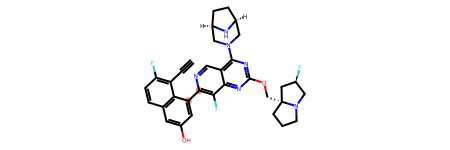

In [37]:
from rdsl import highlight_atoms
mol2d = Chem.Mol(mol)
AllChem.Compute2DCoords(mol2d)
highlight_atoms(mol2d, atom_ids=(12, 15))

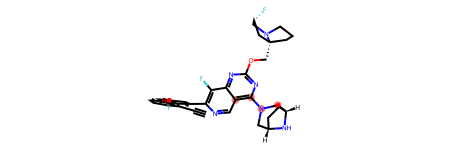

In [242]:
from rdsl import highlight_atoms

highlight_atoms(mol, atom_ids=(0, 8, 9, 20))

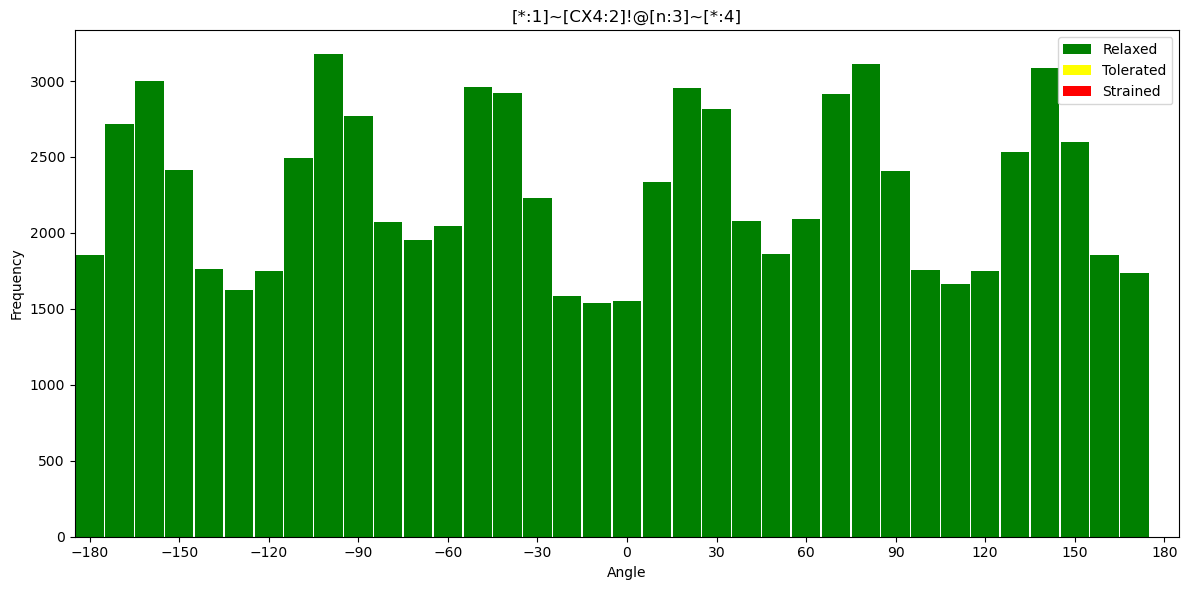

In [188]:
import numpy as np
import matplotlib.pyplot as plt


# Bin centres: -180, -170, ..., 170  (36 bins × 10°)
angles = np.arange(-180, 180, 10)

color_map = {"relaxed": "green", "tolerance": "yellow", "strain": "red"}
colors = [color_map[rule.query(a)["status"]] for a in angles]

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(angles, rule.csd_counts, width=9.5, color=colors, align="center")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green",  label="Relaxed"),
    Patch(facecolor="yellow", label="Tolerated"),
    Patch(facecolor="red",    label="Strained"),
]
ax.legend(handles=legend_elements)

ax.set_xlabel("Angle")
ax.set_ylabel("Frequency")
ax.set_xticks(range(-180, 181, 30))
ax.set_xlim(-185, 185)
ax.set_title(rule.smarts)

plt.tight_layout()
plt.show()

In [185]:
rule

Rule(smarts='[*:1]~[CX4:2]!@[n:3]~[*:4]', level=1, angles=[Angle(value=-60.0, tolerance1=30.0, tolerance2=30.0, score=2.39), Angle(value=60.0, tolerance1=30.0, tolerance2=30.0, score=2.31), Angle(value=180.0, tolerance1=30.0, tolerance2=30.0, score=2.14), Angle(value=120.0, tolerance1=30.0, tolerance2=30.0, score=2.06), Angle(value=-120.0, tolerance1=30.0, tolerance2=30.0, score=1.98), Angle(value=0.0, tolerance1=30.0, tolerance2=30.0, score=1.85)], csd_counts=[1857, 2720, 2999, 2415, 1762, 1622, 1752, 2495, 3175, 2772, 2075, 1952, 2047, 2960, 2920, 2230, 1585, 1538, 1549, 2337, 2952, 2819, 2080, 1864, 2090, 2914, 3114, 2410, 1758, 1665, 1747, 2535, 3089, 2598, 1855, 1738])

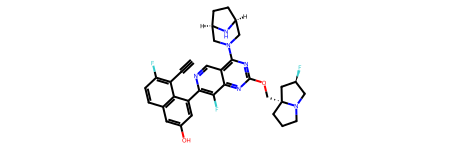

In [187]:
mol

In [ ]:
we need to parse the xml and keep the hierarchy with smarts
 <hierarchyClass id1="N" id2="C" name="NC" smarts="[#7:2]!@[#6:3]">

and relevant subclasses <hierarchySubClass name="Sulfonamide" smarts="[$(S(=O)(=O)):1][N:2]!@[#6:3]">

  for rule in rules:
        matches =  mol.GetSubstructMatches(rule.pattern)
        if len(matches)!=0:
            for match in matches:
                
                degree = rdMolTransforms.GetDihedralDeg(conf, *match[:4])
                print(rule.smarts, rule.level, match, rule.query(degree))
            print(" ")
            # break
        
        

as we should only return 
1) the lowest 
